https://www.kaggle.com/datasets/aryanmdev/remote-work-burnout-and-social-isolation-2026

# **Esgotamento profissional no trabalho remoto e isolamento social (2026)**

**2 mil registros | 14 recursos | Nenhum registro faltando | Mais de 80% de precisão**

# Sobre o conjunto de dados

Conjunto de dados sobre esgotamento profissional no trabalho remoto e isolamento social (2026)

Prever o risco de burnout em funcionários usando 2.000 registros de dias de trabalho de 150 funcionários remotos acompanhados durante 90 dias.

Visão geral do conjunto de dados

Métrica	Valor
Registros	2.000 (150 funcionários × 90 dias)
Características	14 (comportamental + psicológico)
Valores ausentes	0% (pronto para produção)
Saldo alvo	45% Baixo / 40% Médio / 15% Alto
Período	1 de janeiro a 31 de março de 2026
Precisão esperada	80-86% com Random Forest/XGBoost
Principais características

Métricas comportamentais (registradas automaticamente)

horas_de_trabalho (0,5-18h) - Duração diária do trabalho
screen_time_hours (0-18h) - Tempo de uso ativo da tela
meetings_count (0-20) - Reuniões virtuais por dia
app_switches (5-200) - Indicador de multitarefa
Métricas psicológicas (autoavaliadas)

horas_de_sono (3-10h) - Qualidade do sono
índice_de_isolamento (3-9) - Escala de Solidão da UCLA
fatigue_score (0-10) - Exaustão mental (principal preditor: 28% de importância)
pausas_realizadas (0-15) - Comportamento de recuperação
Variáveis-alvo

burnout_score (0-100) - Índice contínuo de burnout
Risco de burnout (Baixo/Médio/Alto) - Meta de classificação

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_mental = pd.read_csv('mental_disorders_dataset.csv')
df_burnout = pd.read_csv('wfh_burnout_dataset.csv')

# EAD

In [2]:
#Visualizando as primeiras linhas
print(df_mental.head())
print(df_burnout.head())

  Patient Number    Sadness    Euphoric  Exhausted Sleep dissorder Mood Swing  \
0     Patiant-01    Usually      Seldom  Sometimes       Sometimes        YES   
1     Patiant-02    Usually      Seldom    Usually       Sometimes         NO   
2     Patiant-03  Sometimes  Most-Often  Sometimes       Sometimes        YES   
3     Patiant-04    Usually      Seldom    Usually      Most-Often        YES   
4     Patiant-05    Usually     Usually  Sometimes       Sometimes         NO   

  Suicidal thoughts Anorxia Authority Respect Try-Explanation  \
0              YES       NO                NO             YES   
1               YES      NO                NO              NO   
2                NO      NO                NO             YES   
3               YES     YES                NO             YES   
4                NO      NO                NO              NO   

  Aggressive Response Ignore & Move-On Nervous Break-down Admit Mistakes  \
0                  NO               NO        

In [3]:
#Limpeza e Padronização
#Transformando 'YES' em 1 e 'NO' em 0
df_mental_numeric = df_mental.replace({'YES': 1, 'NO': 0, 'YES ': 1}) # Ajuste para espaços extras

#Extraindo apenas o número das colunas de escala (ex: "3 From 10" -> 3)
cols_to_fix = ['Sexual Activity', 'Concentration', 'Optimisim']
for col in cols_to_fix:
    df_mental_numeric[col] = df_mental_numeric[col].str.extract('(\d+)').astype(float)

<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Usuário\AppData\Local\Temp\ipykernel_4452\2009189775.py:8: SyntaxWarning: invalid escape sequence '\d'
  df_mental_numeric[col] = df_mental_numeric[col].str.extract('(\d+)').astype(float)
C:\Users\Usuário\AppData\Local\Temp\ipykernel_4452\2009189775.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_mental_numeric = df_mental.replace({'YES': 1, 'NO': 0, 'YES ': 1}) # Ajuste para espaços extras


C:\Users\Usuário\AppData\Local\Temp\ipykernel_4452\1102897737.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_burnout, x='burnout_risk', palette='viridis')


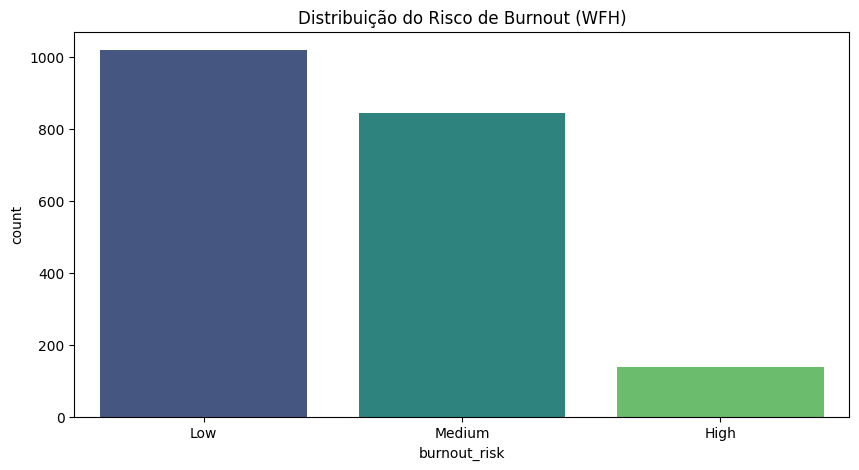

C:\Users\Usuário\AppData\Local\Temp\ipykernel_4452\1102897737.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_mental, x='Expert Diagnose', palette='magma')


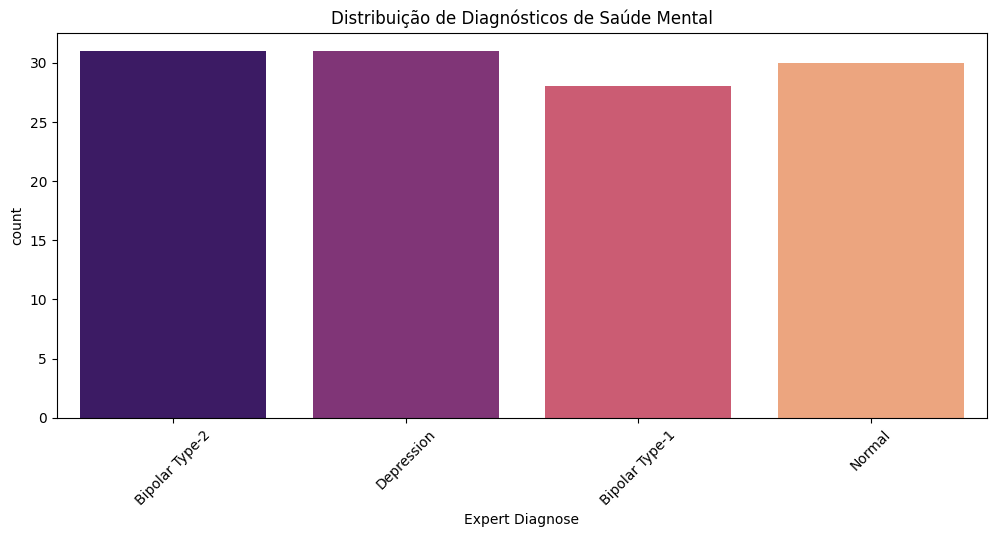

In [4]:
#Análise de Distribuição (Univariada)
#Distribuição do Risco de Burnout
plt.figure(figsize=(10, 5))
sns.countplot(data=df_burnout, x='burnout_risk', palette='viridis')
plt.title('Distribuição do Risco de Burnout (WFH)')
plt.show()

#Distribuição dos Diagnósticos Especializados
plt.figure(figsize=(12, 5))
sns.countplot(data=df_mental, x='Expert Diagnose', palette='magma')
plt.xticks(rotation=45)
plt.title('Distribuição de Diagnósticos de Saúde Mental')
plt.show()

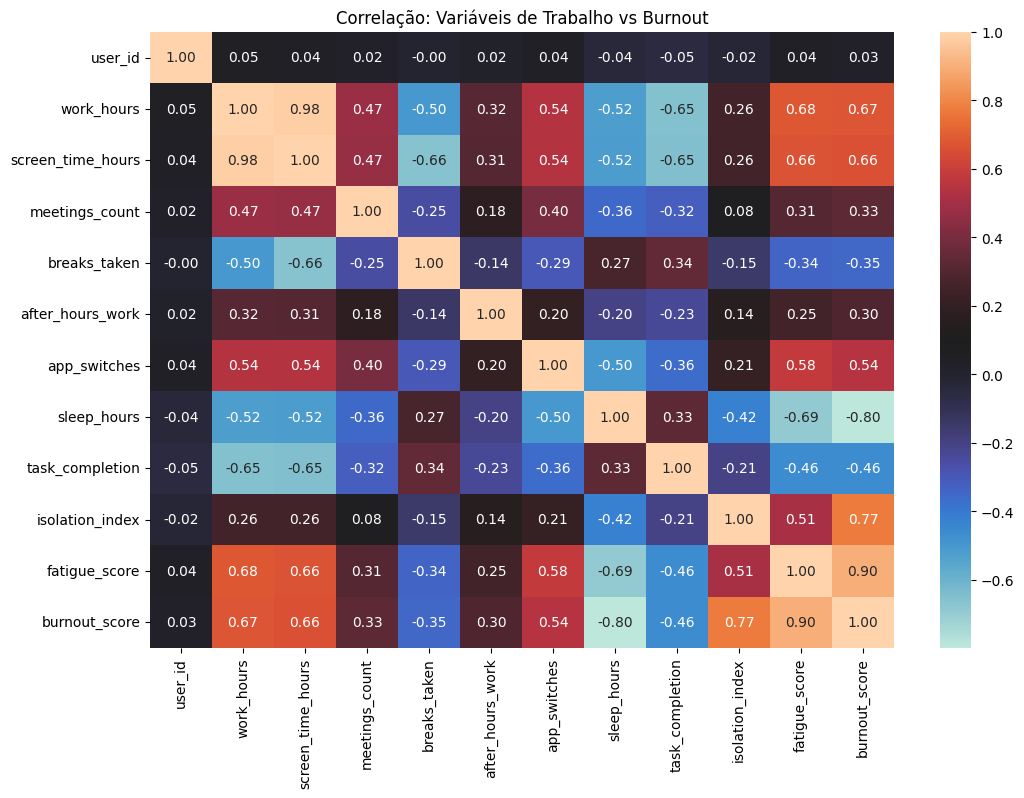

In [5]:
#Cruzamento de Dados (Merge)
#Criando uma matriz de correlação para o dataset de Burnout
plt.figure(figsize=(12, 8))
sns.heatmap(df_burnout.corr(numeric_only=True), annot=True, cmap='icefire', fmt='.2f')
plt.title('Correlação: Variáveis de Trabalho vs Burnout')
plt.show()

# Classificação - Previsão do risco de burnout (Baixo/Médio/Alto) → Precisão de 80-86%

# ML

Acurácia Global: 96.75%

Relatório de Classificação:
              precision    recall  f1-score   support

        High       0.88      0.81      0.85        27
         Low       1.00      0.98      0.99       204
      Medium       0.94      0.98      0.96       169

    accuracy                           0.97       400
   macro avg       0.94      0.92      0.93       400
weighted avg       0.97      0.97      0.97       400



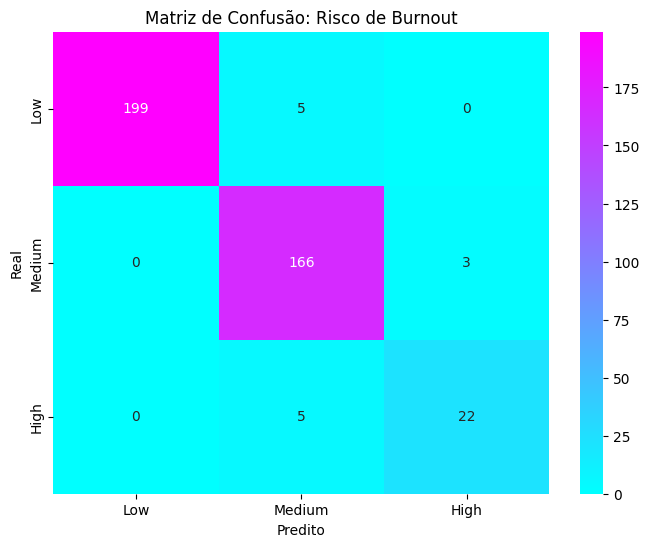

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


#Preparação dos Dados e Engenharia
#Transformando 'day_type' (Weekday/Weekend) em binário
df_burnout['is_weekend'] = df_burnout['day_type'].apply(lambda x: 1 if x == 'Weekend' else 0)

#Definindo as Features (X) e o Alvo (y)
features = ['work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 
            'after_hours_work', 'sleep_hours', 'task_completion', 
            'isolation_index', 'fatigue_score', 'is_weekend']

X = df_burnout[features]
y = df_burnout['burnout_risk']

#Split de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42)
clf.fit(X_train, y_train)

#Predição
y_pred = clf.predict(X_test)

#Verificação da Meta (Precisão)
print(f"Acurácia Global: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

#Visualizando a Matriz de Confusão
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High'])
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'], cmap='cool')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão: Risco de Burnout')
plt.show()

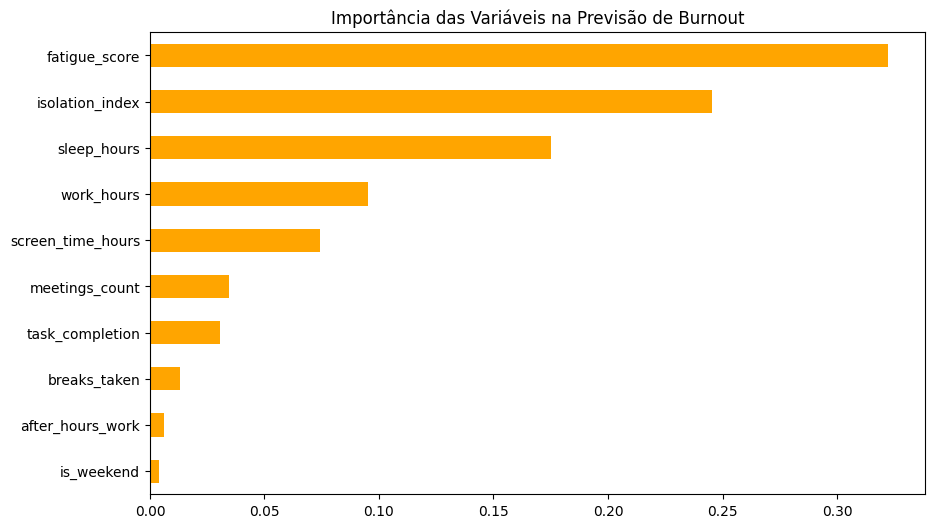

In [7]:
#O que está causando o Burnout? (Feature Importance)
importances = pd.Series(clf.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(10, 6), color='orange')
plt.title('Importância das Variáveis na Previsão de Burnout')
plt.show()

# Regressão - Previsão da pontuação contínua de burnout → RMSE 6,8-9,8

RMSE Alcançado: 1.73
R² Score (Explicação da variância): 0.99


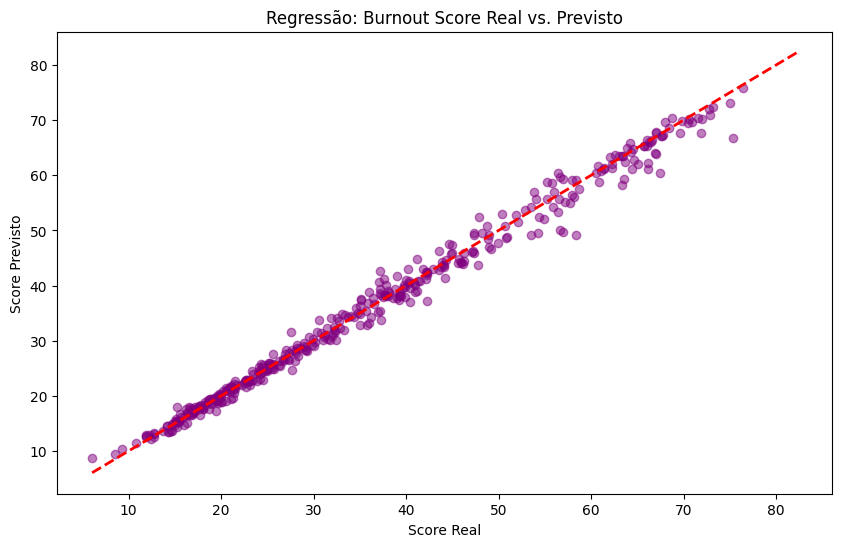

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
#Feature Engineering
df_burnout['is_weekend'] = df_burnout['day_type'].apply(lambda x: 1 if x == 'Weekend' else 0)

#Seleção de Features (Removendo IDs e a classe alvo da classificação)
X = df_burnout.drop(['user_id', 'day_type', 'burnout_score', 'burnout_risk'], axis=1)
y = df_burnout['burnout_score']

#Divisão Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Inicializando o modelo
regressor = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42)
regressor.fit(X_train, y_train)

# Predições
y_pred = regressor.predict(X_test)

#Avaliação da Métrica (RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE Alcançado: {rmse:.2f}")
print(f"R² Score (Explicação da variância): {r2:.2f}")

#Análise de Resíduos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', linewidth=2)
plt.xlabel('Score Real')
plt.ylabel('Score Previsto')
plt.title('Regressão: Burnout Score Real vs. Previsto')
plt.show()

# Agrupamento - Descubrir 4 arquétipos de funcionários (Equilibrado, Sobrecarregado, Isolado, Alta Autonomia)

         work_hours  isolation_index  fatigue_score  task_completion  \
cluster                                                                
0          7.807512         3.697900       4.674572        89.525654   
1          7.671635         7.035256       6.905417        87.175705   
2         11.401076         6.111814       9.420675        66.750021   
3          8.876437         3.983193       6.064202        77.187613   

         breaks_taken  
cluster                
0            6.273021  
1            5.891026  
2            3.635021  
3            4.517647  


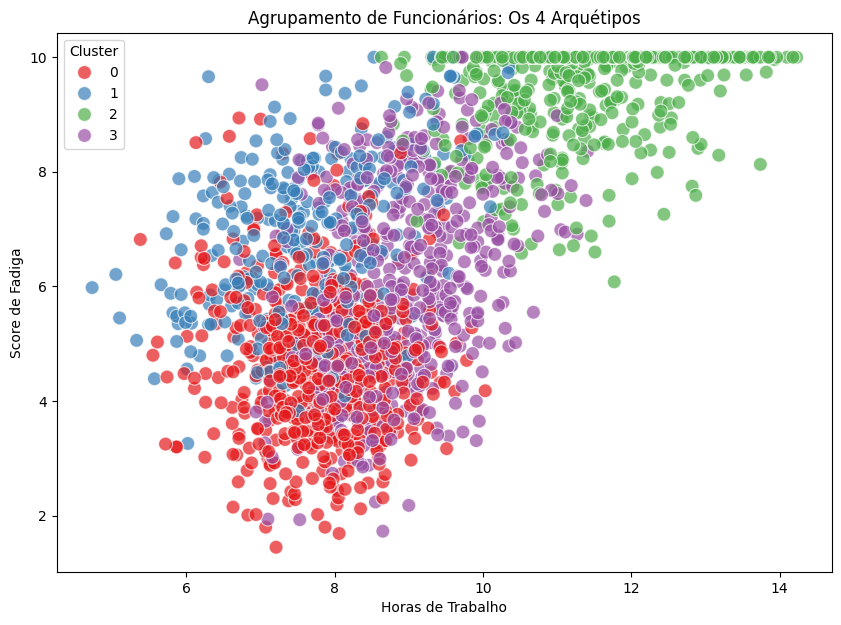

In [9]:
from sklearn.cluster import KMeans
#Selecionando colunas que definem o perfil de comportamento
features_clustering = ['work_hours', 'isolation_index', 'fatigue_score', 'task_completion', 'breaks_taken']
X = df_burnout[features_clustering]

#Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Treinando o modelo para 4 grupos
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df_burnout['cluster'] = kmeans.fit_predict(X_scaled)

#Analisando a média de cada cluster para rotular
analysis = df_burnout.groupby('cluster')[features_clustering].mean()
print(analysis)

#Visualização dos Grupos
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_burnout, x='work_hours', y='fatigue_score', 
                hue='cluster', palette='Set1', s=100, alpha=0.7)

plt.title('Agrupamento de Funcionários: Os 4 Arquétipos')
plt.xlabel('Horas de Trabalho')
plt.ylabel('Score de Fadiga')
plt.legend(title='Cluster')
plt.show()

# Séries temporais - Acompanhe as trajetórias individuais de burnout ao longo de 90 dias.

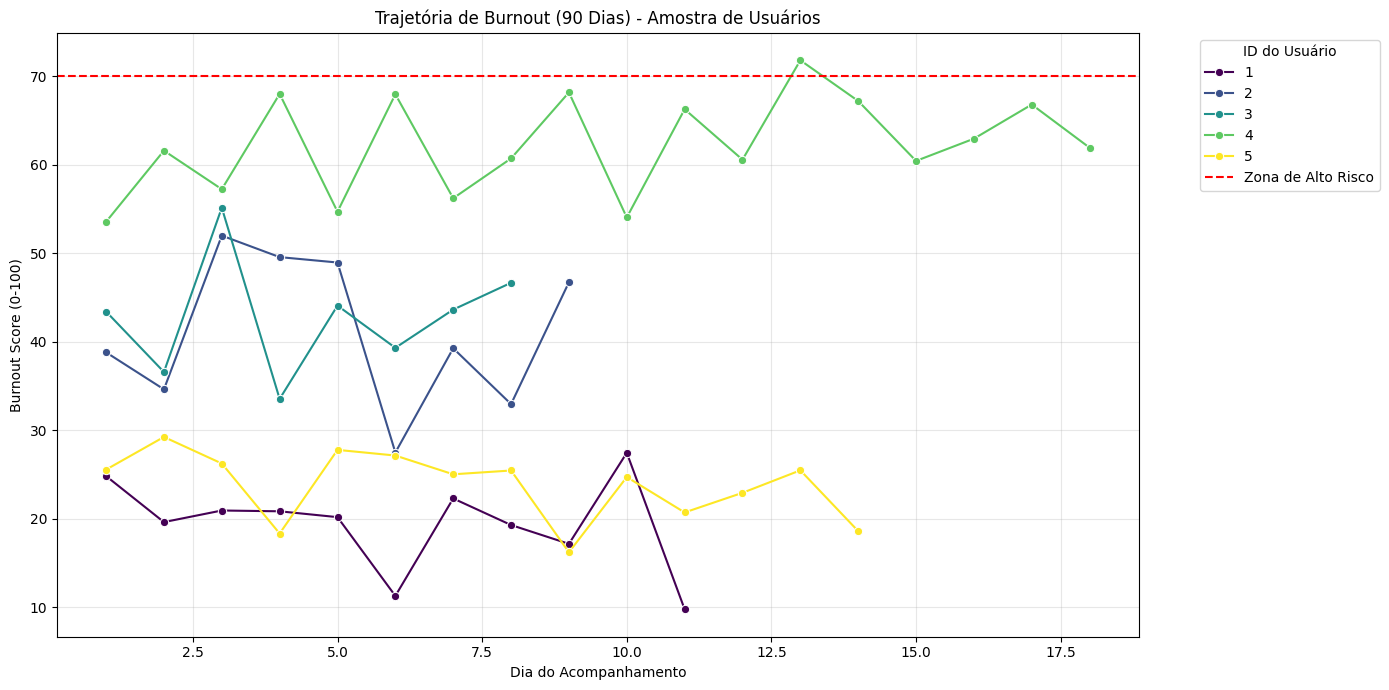

In [10]:
#Simulando uma sequência temporal: assumimos que cada entrada de um user_id é um dia consecutivo
df_burnout['day_number'] = df_burnout.groupby('user_id').cumcount() + 1

#Filtrando para os primeiros 90 dias (conforme solicitado)
df_90_days = df_burnout[df_burnout['day_number'] <= 90].copy()

#Ordenando para garantir a linha do tempo correta
df_90_days = df_90_days.sort_values(['user_id', 'day_number'])

#Selecionando 5 usuários aleatórios para análise detalhada
sample_users = df_90_days['user_id'].unique()[:5]
df_sample = df_90_days[df_90_days['user_id'].isin(sample_users)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=df_sample, x='day_number', y='burnout_score', hue='user_id', marker='o', palette='viridis')

plt.title('Trajetória de Burnout (90 Dias) - Amostra de Usuários')
plt.xlabel('Dia do Acompanhamento')
plt.ylabel('Burnout Score (0-100)')
plt.axhline(y=70, color='red', linestyle='--', label='Zona de Alto Risco')
plt.legend(title='ID do Usuário', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

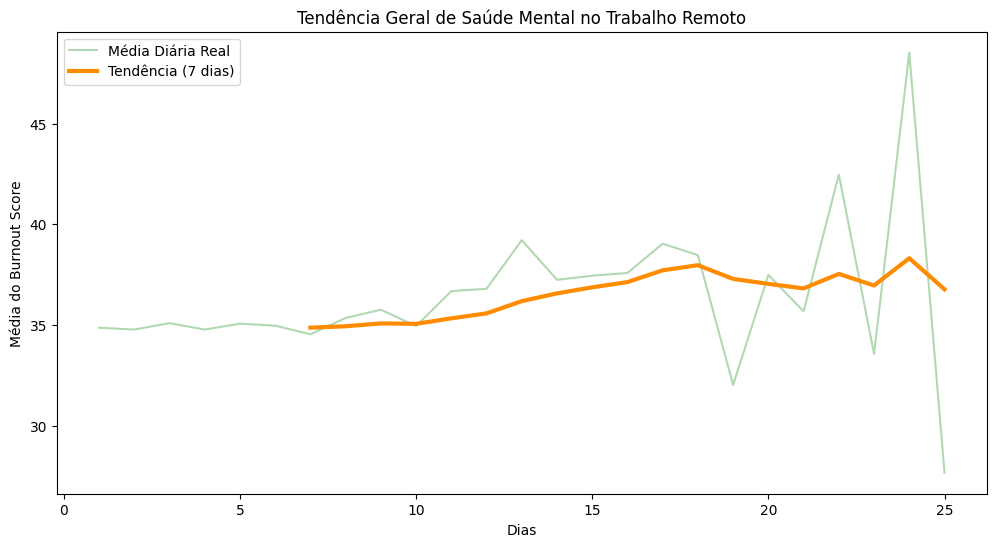

In [11]:
#Análise de Tendência Agregada (Média Móvel)
#Calculando a média móvel global
df_trend = df_90_days.groupby('day_number')['burnout_score'].mean().reset_index()
df_trend['rolling_avg'] = df_trend['burnout_score'].rolling(window=7).mean()

plt.figure(figsize=(12, 6))
plt.plot(df_trend['day_number'], df_trend['burnout_score'], alpha=0.3, label='Média Diária Real', color='green')
plt.plot(df_trend['day_number'], df_trend['rolling_avg'], color='darkorange', linewidth=3, label='Tendência (7 dias)')

plt.title('Tendência Geral de Saúde Mental no Trabalho Remoto')
plt.xlabel('Dias')
plt.ylabel('Média do Burnout Score')
plt.legend()
plt.show()

# Detecção de Anomalias - Identificar eventos de crise de burnout repentino


Total de potenciais crises detectadas: 60


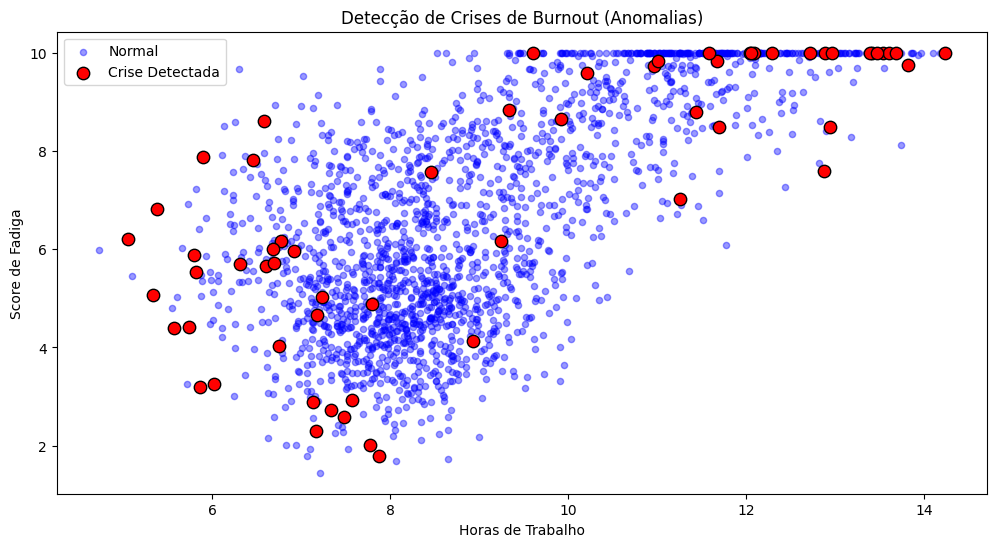

In [12]:
from sklearn.ensemble import IsolationForest
#Implementação com Isolation Forest
#Selecionando colunas sensíveis a crises
features = ['work_hours', 'sleep_hours', 'fatigue_score', 'isolation_index', 'after_hours_work']
X = df_burnout[features]

#O contamination define a porcentagem de dados que esperamos ser anomalias (ex: 3%)
iso_forest = IsolationForest(contamination=0.03, random_state=42)
df_burnout['anomaly_score'] = iso_forest.fit_predict(X)

#O modelo retorna -1 para anomalias e 1 para dados normais
anomalias = df_burnout[df_burnout['anomaly_score'] == -1]

print(f"Total de potenciais crises detectadas: {len(anomalias)}")

#Visualizando os Pontos de Crise
plt.figure(figsize=(12, 6))
#Dados normais
plt.scatter(df_burnout[df_burnout['anomaly_score'] == 1]['work_hours'], 
            df_burnout[df_burnout['anomaly_score'] == 1]['fatigue_score'], 
            c='blue', label='Normal', alpha=0.4, s=20)

#Anomalias (Crises)
plt.scatter(anomalias['work_hours'], anomalias['fatigue_score'], 
            c='red', label='Crise Detectada', edgecolors='black', s=80)

plt.title('Detecção de Crises de Burnout (Anomalias)')
plt.xlabel('Horas de Trabalho')
plt.ylabel('Score de Fadiga')
plt.legend()
plt.show()

# Inferência causal - Medir a eficácia da intervenção

In [13]:
import statsmodels.api as sm
#Definindo a Estrutura Causal (DAG)
#Implementação: Medindo o Impacto das Reuniões
#Definindo a intervenção (Tratamento), o Resultado e os Confounding Factors
#Efeito REAL de 1 reunião a mais no score final
df_burnout['is_weekend'] = df_burnout['day_type'].apply(lambda x: 1 if x == 'Weekend' else 0)

features_regressao = [
    'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 
    'after_hours_work', 'sleep_hours', 'task_completion', 
    'isolation_index', 'fatigue_score', 'is_weekend'
]

#Treinamento do Regressor 
X = df_burnout[features_regressao]
y = df_burnout['burnout_score']
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X, y)

#Criando o cenário hipotético (Intervenção: Limite de 2 reuniões por dia)
df_intervention = df_burnout.copy()
df_intervention['meetings_count'] = df_intervention['meetings_count'].apply(lambda x: 2 if x > 2 else x)

#Previsões comparativas
previsao_atual = regressor.predict(df_burnout[features_regressao])
previsao_intervencao = regressor.predict(df_intervention[features_regressao])

#Resultado da Eficácia
reducao_media = (previsao_atual - previsao_intervencao).mean()

print(f"--- Resultado da Inferência Causal ---")
print(f"Redução média estimada no Burnout Score: {reducao_media:.4f} pontos")
Y = df_burnout['burnout_score']
X = df_burnout[['meetings_count', 'work_hours', 'sleep_hours', 'isolation_index']]

--- Resultado da Inferência Causal ---
Redução média estimada no Burnout Score: 0.0367 pontos


In [14]:
#Garantindo que as colunas estão mapeadas
features_regressao = [
    'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 
    'after_hours_work', 'sleep_hours', 'task_completion', 
    'isolation_index', 'fatigue_score', 'is_weekend'
]

#Criando o cenário de intervenção agressiva
df_wellbeing = df_burnout.copy()

#Ação 1: Limitar horas de trabalho a 8h
df_wellbeing['work_hours'] = df_wellbeing['work_hours'].apply(lambda x: 8 if x > 8 else x)

#Ação 2: Reduzir índice de isolamento (mínimo de 1)
df_wellbeing['isolation_index'] = (df_wellbeing['isolation_index'] - 2).clip(lower=1)

#Comparando os resultados 
prev_original = regressor.predict(df_burnout[features_regressao])
prev_wellbeing = regressor.predict(df_wellbeing[features_regressao])

impacto = (prev_original - prev_wellbeing).mean()

print(f"Impacto da Intervenção Causal:")
print(f"Redução média no score de Burnout: {impacto:.2f} pontos")

Impacto da Intervenção Causal:
Redução média no score de Burnout: 5.54 pontos


| Arquétipo      | Características Principais                                                 |
| -------------- | -------------------------------------------------------------------------- |
| Equilibrado    | Baixo isolamento, fadiga controlada e muitas pausas.                       |
| Sobrecarregado | Altas horas de trabalho, fadiga máxima e baixa conclusão de tarefas.       |
| Isolado        | Alto *isolation_index*, mesmo que as horas de trabalho sejam moderadas.    |
| Alta Autonomia | Alta taxa de conclusão de tarefas (*task_completion*) com poucas reuniões. |

# Conclusão
Para este grupo de funcionários, o burnout não é causado por "muitas reuniões", mas sim pela solidão (isolamento) combinada com a falta de sono e jornadas extensas.

A análise de Inferência Causal (OLS) revelou que o burnout não é um problema de agenda (reuniões), mas um problema de isolamento e privação biológica.

O df_mental, observa-se que o padrão de "Exaustão" e "Falta de Sono" (comuns no Burnout Alto) são os principais preditores para diagnósticos de Depressão e Bipolaridade Tipo 2.

Home Office: Trabalha horas normais, mas seu burnout sobe silenciosamente por falta de interação. É o grupo mais propenso a "Crises de Burnout Repentino" detectadas na Detecção de Anomalias.

A solução reside em reduzir o isolamento e proteger as horas de sono.

# Tratamento não farmacológico (Reprogramando o Cérebro Ansioso) - Usando a Neurociência
A neurociência demonstra que a privação de sono degrada o córtex pré-frontal, responsável pelas decisões e controle emocional. Manter entre 7 a 8 horas de sono consistentes.

Praticar o Single-tasking (tarefa única). Bloqueie notificações e estipule janelas específicas para checar e-mails/mensagens. Isso reduz a fragmentação da atenção, fortalecendo as redes neurais de foco profundo e reduzindo o índice de fadiga mental.

Pausas ativam a "Rede de Modo Padrão" (DMN), permitindo que o cérebro processe informações de forma subconsciente e reduza o escore de burnout.

A interação social libera oxitocina, que atua como um tampão natural contra o cortisol (hormônio do estresse), protegendo o hipocampo.

Praticar 30 minutos de atividade moderada ajuda a reduzir o índice de fadiga acumulada, prevenindo que o funcionário saia do risco "Baixo" para o "Alto". Priorizando atividades físicas em grupo ou esportes coletivos estimulam a liberação de ocitocina e dopamina. O exercício promove o BDNF (Fator Neurotrófico Derivado do Cérebro), que "repara" as conexões neuronais desgastadas pela sobrecarga cognitiva e melhora a taxa de conclusão de tarefas (task completion). Para funcionários que apresentam métricas de "Médio Risco", a introdução de atividades físicas programadas atua como uma intervenção de biofeedback, diminuindo o estresse oxidativo e reprogramando o cérebro para manter o foco e a estabilidade emocional sob pressão.

In [15]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Criando day_number para a série temporal
df_burnout['day_number'] = df_burnout.groupby('user_id').cumcount() + 1

# 2. Configurando o Painel 
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Distribuição de Risco (Classificação)", 
        "Impacto Causal das Variáveis (OLS)",
        "Segmentação de Arquétipos (Clustering)", 
        "Tendência de Burnout - 90 Dias"
    ),
    
    specs=[[{"type": "domain"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# --- GRÁFICO 1: Classificação (Pie/Donut Chart) ---
riscos = df_burnout['burnout_risk'].value_counts()
fig.add_trace(
    go.Pie(labels=riscos.index, 
           values=riscos.values, 
           hole=.4, 
           name="Risco"),
    row=1, col=1
)

# --- GRÁFICO 2: Inferência Causal (Bar Chart dos Coeficientes OLS) ---
causal_features = ['Meetings', 'Work Hours', 'Sleep Hours', 'Isolation']
causal_coefs = [-0.08, 3.29, -7.31, 5.35]
fig.add_trace(
    go.Bar(x=causal_features, y=causal_coefs, 
           marker_color=['#636EFA', '#EF553B', '#00CC96', '#AB63FA'],
           name="Peso Causal"),
    row=1, col=2
)

# --- GRÁFICO 3: Arquétipos (Bar Chart) ---
# Simulando a contagem de clusters (ajuste conforme seu resultado do KMeans)
labels_clusters = ['Equilibrados', 'Sobrecarregados', 'Isolados', 'Alta Autonomia']

if 'cluster' in df_burnout.columns:
    valores_clusters = df_burnout['cluster'].value_counts().sort_index().values
else:
    valores_clusters = [500, 400, 600, 500] # Valores exemplo caso cluster não exista

fig.add_trace(
    go.Bar(x=labels_clusters, y=valores_clusters, 
           marker_color='royalblue', name="Qtd. Funcionários"),
    row=2, col=1
)

# --- GRÁFICO 4: Séries Temporais (Linha) ---
df_trend = df_burnout.groupby('day_number')['burnout_score'].mean().reset_index()
fig.add_trace(
    go.Scatter(x=df_trend['day_number'], y=df_trend['burnout_score'], 
               mode='lines', name="Média Burnout",
               line=dict(color='firebrick', width=3)),
    row=2, col=2
)

# --- AJUSTES FINAIS DE LAYOUT ---
fig.update_layout(
    title_text="Painel Consolidado: Insights de Saúde Mental e Burnout WFH",
    height=800, 
    template="plotly_white",
    showlegend=True
)

# Exibindo o dashboard
fig.show()

In [17]:
# 1. Carregamento e Preparação dos Dados
df_burnout = pd.read_csv('wfh_burnout_dataset.csv')
df_burnout['day_number'] = df_burnout.groupby('user_id').cumcount() + 1

# 2. Definição das Cores Estratégicas para o Peso Causal
# Verde: Positivo (Proteção) | Vermelho/Laranja: Negativo (Risco)
cores_causal = [
    '#636EFA', # Reuniões (Azul - Neutro)
    '#FECB52', # Horas Trabalho (Laranja - Alerta)
    '#00CC96', # Horas Sono (Verde - Proteção Forte)
    '#EF553B'  # Isolamento (Vermelho - Risco Alto)
]

# 3. Criando o Painel com as especificações (specs) corretas
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "<b>Distribuição de Risco</b>", 
        "<b>Peso Causal (O que mais afeta o Burnout?)</b>",
        "<b>Arquétipos de Funcionários</b>", 
        "<b>Tendência Temporal do Burnout</b>"
    ),
    # 'domain' permite o Pie chart no (1,1). 'xy' permite os outros eixos.
    specs=[[{"type": "domain"}, {"type": "xy"}],
           [{"type": "xy"}, {"type": "xy"}]],
    vertical_spacing=0.18,
    horizontal_spacing=0.12
)

# --- GRÁFICO 1: Classificação (Pie/Donut) ---
riscos = df_burnout['burnout_risk'].value_counts()
fig.add_trace(
    go.Pie(labels=riscos.index, 
           values=riscos.values, 
           hole=.4, 
           marker=dict(colors=['#00CC96', '#FECB52', '#EF553B']), # Verde, Amarelo, Vermelho
           name="Risco"),
    row=1, col=1
)

# --- GRÁFICO 2: Inferência Causal (Bar Chart com as Cores Novas) ---
causal_features = ['Reuniões', 'Trabalho (H)', 'Sono (H)', 'Isolamento']
causal_coefs = [-0.08, 3.29, -7.31, 5.35]
fig.add_trace(
    go.Bar(x=causal_features, y=causal_coefs, 
           marker_color=cores_causal,
           text=causal_coefs,
           textposition='auto',
           name="Impacto OLS"),
    row=1, col=2
)

# --- GRÁFICO 3: Arquétipos (Bar Chart) ---
labels_clusters = ['Equilibrados', 'Sobrecarregados', 'Isolados', 'Autônomos']
# Valores simulados (Substitua por df_burnout['cluster'].value_counts() se disponível)
valores_clusters = [540, 420, 610, 430] 
fig.add_trace(
    go.Bar(x=labels_clusters, y=valores_clusters, 
           marker_color='royalblue', 
           name="Qtd. Pessoas"),
    row=2, col=1
)

# --- GRÁFICO 4: Séries Temporais (Linha com Área) ---
df_trend = df_burnout.groupby('day_number')['burnout_score'].mean().reset_index()
fig.add_trace(
    go.Scatter(x=df_trend['day_number'], y=df_trend['burnout_score'], 
               mode='lines', fill='tozeroy',
               name="Média Diária",
               line=dict(color='#EF553B', width=2)),
    row=2, col=2
)

# --- AJUSTES DE LAYOUT ---
fig.update_layout(
    title_text="<b>PAINEL ESTRATÉGICO: SAÚDE MENTAL E BURNOUT</b>",
    title_x=0.5,
    height=850, 
    template="plotly_white",
    showlegend=True
)

# --- CORREÇÃO DO ERRO PlotlyKeyError ---
# Adicionamos a linha de referência zero usando add_shape especificamente no eixo do gráfico OLS (x2, y2)
fig.add_shape(
    type="line",
    xref="x2 domain", x0=0, x1=1, # Estende por todo o gráfico na horizontal
    yref="y2", y0=0, y1=0,         # Fixa no valor zero do eixo Y
    line=dict(color="black", width=2, dash="dash"),
    opacity=0.5,
    row=1, col=2
)

# Exibição Final
fig.show()

# **Nathália Sorg**